In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 13

import keras
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten #, Reshape
from keras.layers import Conv1D, MaxPooling1D, GlobalMaxPooling1D, AveragePooling1D

### Read data

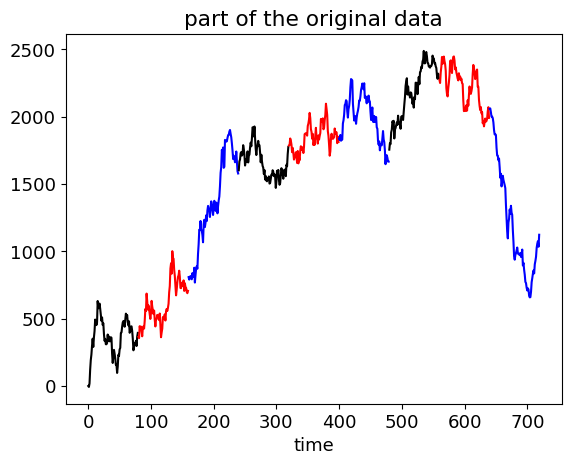

data:  4000


In [2]:
def Show_data(x,L,s="data",T=3):
    c=("k","r","b")
    for i in range(T):
        j=i*3*L
        plt.plot(np.arange(j,j+L),x[i*3],c=c[0])
        plt.plot(np.arange(j+L,j+2*L),x[i*3+1],c=c[1])
        plt.plot(np.arange(j+2*L,j+3*L),x[i*3+2],c=c[2])
    plt.title(s)
    plt.xlabel("time")
    plt.show()
    
str0="ts_L80_N4000.dat"
fnamex='x_'+str0
fnamey='y_'+str0

x = np.loadtxt(fnamex, delimiter=" ",dtype=float)
N,L = len(x), len(x[0])

Show_data(x,L,"part of the original data")

categ = np.loadtxt(fnamey, dtype=int)
n_class = 3    # y.argmax() - y.argmin() +1
print('data: ',N)

y = np.zeros((N,n_class))
for i in range(N):
    y[i][categ[i]] = 1.

### Rescale data, split train/val.

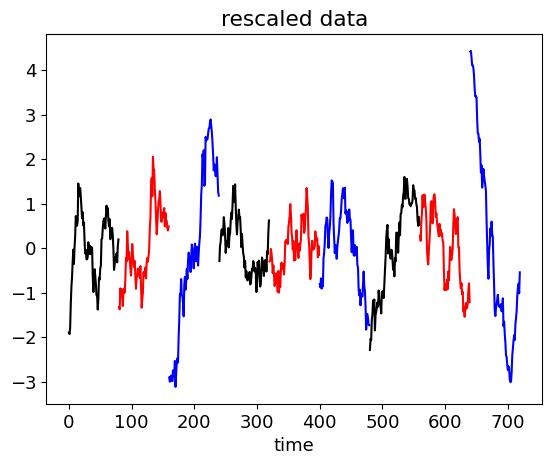

N_train= 3200   N_val= 800   L= 80   n_class= 3


In [3]:
#
#  FIRST PASSAGE:  DO NOT DO THIS --> FAILURE 
#
# bring each sample to zero average
xm = x.mean(axis=1)
for i in range(N):
    x[i] = x[i]-xm[i]

#
#  SECOND PASSAGE:  DO NOT DO THIS --> ALSO FAILURE 
#
#rescale (crude version, variance should be used)
x = x / x.std()
    
Show_data(x,L,"rescaled data")

perc_train=0.8
N_train = int(perc_train*N)
x_train = x[:N_train]
y_train = y[:N_train]
x_val = x[N_train:]
y_val = y[N_train:]
N_val = len(x_val)
print('N_train=',N_train,'  N_val=',N_val,'  L=',L,'  n_class=',n_class)

# Keras wants an additional dimension with a 1 at the end
x_train = x_train.reshape(x_train.shape[0], L, 1)
x_val =  x_val.reshape(x_val.shape[0], L, 1)
input_shape = (L, 1)

## Convolutional NN

In [4]:
# ...LESSON ...
# reproducibility
np.random.seed(12345)
import tensorflow.random as tf_r
tf_r.set_seed(12345)

NCONV=1

def build_model(NCONV=1, NF=5,KS=6, NF2=5,KS2=4, lamb=0):
    """
    filter = kernel
    NCONV=index of the CNN architecture
    NF=nr of filters in the 1st layer
    KS=kernel size in the 1st layer
    NF2=nr of filters in the 2nd layer
    KS2=kernel size in the 2nd layer
    lamb=not the animal, but lambda, the regularization parameter
    """
    # regularizers, l2=Ridge, l1=LASSO
    reg = keras.regularizers.l2(lamb)
    model = Sequential()

    # Version with last layer Dense
    if NCONV==1:
        model.add(Conv1D(filters=5, 
                         kernel_size=KS,
                         kernel_regularizer=reg,
                         activation='relu', 
                         input_shape=input_shape))
        model.add(MaxPooling1D(3))
        #model.add(AveragePooling1D(3))
        model.add(Conv1D(filters=NF2, kernel_size=KS2,activation='relu'))
        model.add(Flatten())
        model.add(Dense(12, activation='relu'))
        model.add(Dropout(0.2))

    # Version with last layer GlobalMaxPooling, one more intermediate conv1D, and no intermediate pooling
    if NCONV==2:
        model.add(Conv1D(filters=NF, 
                         kernel_size=KS,
                         kernel_regularizer=reg,
                         activation='relu', 
                         input_shape=input_shape))
        model.add(Conv1D(filters=NF2, kernel_size=KS2,activation='relu'))
        model.add(Conv1D(filters=NF2, kernel_size=KS2,activation='relu'))
        model.add(tf.keras.layers.GlobalMaxPooling1D())
        model.add(Flatten())
        
    # Last layer, with n_class units  
    model.add(Dense(n_class, activation='softmax')) # softmax !
    
    # optimizers
    # .SGD(lr=0.01, momentum=0.9, nesterov=True) # decay=1e-6,
    # .RMSprop()
    # .Nadam()
    # Define the optimizer learning rate as a hyperparameter.
    opt = keras.optimizers.Adam()
    
    # compile the model
    # categorical_crossentropy, 3 output nodes
    model.compile(loss=keras.losses.categorical_crossentropy,optimizer=opt,metrics=['accuracy'])
    return model

model=build_model(NCONV=NCONV,KS=11)


print('----- Model',NCONV,'-----')
print(model.summary())

# optimizers
# .SGD(lr=0.01, momentum=0.9, nesterov=True) # decay=1e-6,
# .RMSprop()
# .Nadam()
opt = tf.keras.optimizers.Adam()

# compile the model
# categorical_crossentropy, 3 output nodes
model.compile(loss=keras.losses.categorical_crossentropy,
              optimizer=opt,metrics=['accuracy'])

print(model.layers)

----- Model 1 -----
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d (Conv1D)             (None, 70, 5)             60        
                                                                 
 max_pooling1d (MaxPooling1D  (None, 23, 5)            0         
 )                                                               
                                                                 
 conv1d_1 (Conv1D)           (None, 20, 5)             105       
                                                                 
 flatten (Flatten)           (None, 100)               0         
                                                                 
 dense (Dense)               (None, 12)                1212      
                                                                 
 dropout (Dropout)           (None, 12)                0         
                                    

[<keras.layers.convolutional.conv1d.Conv1D object at 0x17c742350>, <keras.layers.pooling.max_pooling1d.MaxPooling1D object at 0x17c773510>, <keras.layers.convolutional.conv1d.Conv1D object at 0x17c771ed0>, <keras.layers.reshaping.flatten.Flatten object at 0x17c771fd0>, <keras.layers.core.dense.Dense object at 0x17c7bd250>, <keras.layers.regularization.dropout.Dropout object at 0x17c704ad0>, <keras.layers.core.dense.Dense object at 0x17c78c990>]


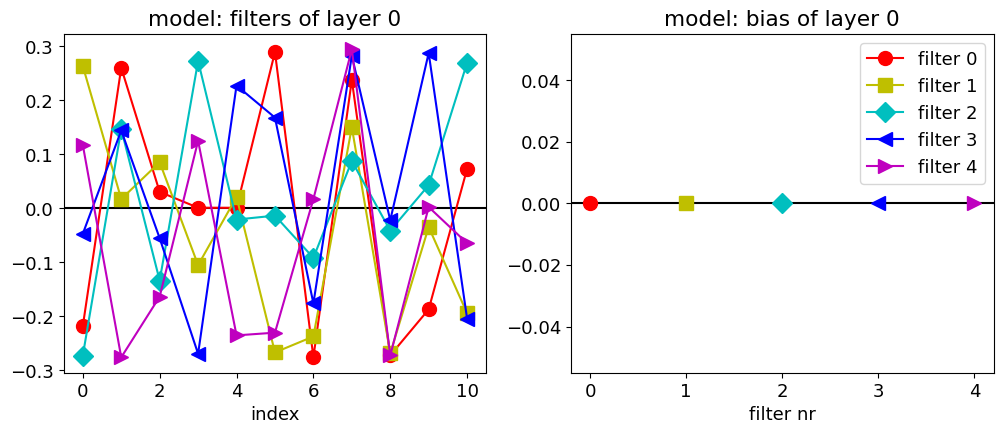

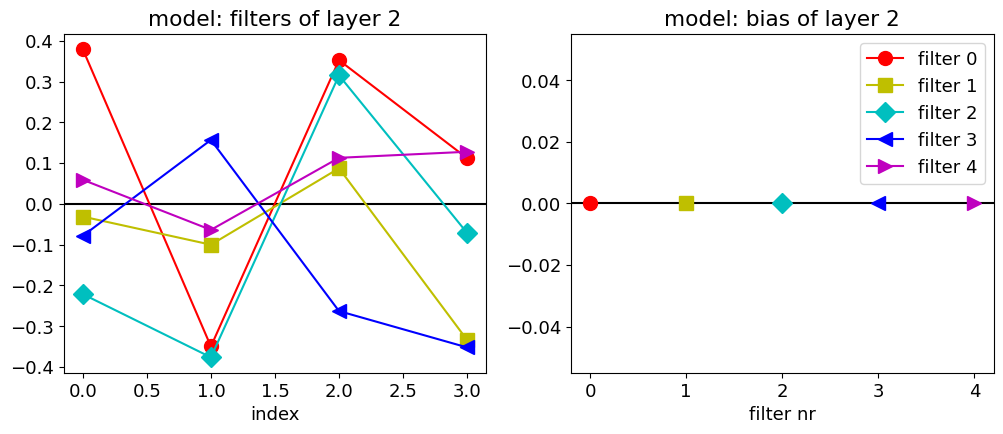

In [5]:
def Show_weights(model,l=0,label="model"):
    c=['r','y','c','b','m','k',"gray","cyan","g"]
    m=['o','s','D','<','>','^','+','x','d',"*"]
    ms=10
    
    w = model.layers[l].get_weights()[0]
    wT=w.T
    M=len(wT)
    b = model.layers[l].get_weights()[1]
    
    fig,AX=plt.subplots(1,2,figsize=(12,4.4))
    ax=AX[0]
    ax.axhline(0, c="k")
    ax.plot((0,))
    for i in range(M):
        ax.plot(wT[i][0],"-",c=c[i%len(c)],marker=m[i%len(m)],label=str(i),markersize=ms)
    ax.set_title(label+': filters of layer '+str(l))
    ax.set_xlabel('index')
    ax=AX[1]
    ax.axhline(0, c="k")
    for i in range(M):
        ax.plot((i),(b[i]),c=c[i%len(c)],marker=m[i%len(m)],label="filter "+str(i),markersize=ms)
    ax.set_title(label+': bias of layer '+str(l))
    ax.set_xlabel('filter nr')
    ax.set_xticks(np.arange(5))
    ax.legend()
    plt.show()
    
Show_weights(model,0)
Show_weights(model,2)

In [6]:
# ...LESSON ...
# Hyper-parameters
# with small minibatch it does not converge!! 
BATCH_SIZE = 200
EPOCHS = 300

print('----- Model ',NCONV,'-----\nFITTING....')
fit = model.fit(x_train,y_train,batch_size=BATCH_SIZE,
                epochs=EPOCHS,
                validation_data=(x_val, y_val),
                verbose=2, shuffle=True) 
print("end of fit")

----- Model  1 -----
FITTING....
Epoch 1/300


2024-03-04 11:02:08.809244: W tensorflow/tsl/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz


16/16 - 0s - loss: 1.1064 - accuracy: 0.3216 - val_loss: 1.1000 - val_accuracy: 0.3375 - 293ms/epoch - 18ms/step
Epoch 2/300
16/16 - 0s - loss: 1.0992 - accuracy: 0.3497 - val_loss: 1.0977 - val_accuracy: 0.3388 - 42ms/epoch - 3ms/step
Epoch 3/300
16/16 - 0s - loss: 1.0975 - accuracy: 0.3475 - val_loss: 1.0970 - val_accuracy: 0.3525 - 38ms/epoch - 2ms/step
Epoch 4/300
16/16 - 0s - loss: 1.0955 - accuracy: 0.3578 - val_loss: 1.0954 - val_accuracy: 0.3413 - 38ms/epoch - 2ms/step
Epoch 5/300
16/16 - 0s - loss: 1.0939 - accuracy: 0.3663 - val_loss: 1.0949 - val_accuracy: 0.3512 - 37ms/epoch - 2ms/step
Epoch 6/300
16/16 - 0s - loss: 1.0941 - accuracy: 0.3653 - val_loss: 1.0932 - val_accuracy: 0.3575 - 38ms/epoch - 2ms/step
Epoch 7/300
16/16 - 0s - loss: 1.0920 - accuracy: 0.3794 - val_loss: 1.0911 - val_accuracy: 0.3537 - 39ms/epoch - 2ms/step
Epoch 8/300
16/16 - 0s - loss: 1.0892 - accuracy: 0.3909 - val_loss: 1.0895 - val_accuracy: 0.3638 - 46ms/epoch - 3ms/step
Epoch 9/300
16/16 - 0s - l

Epoch 68/300
16/16 - 0s - loss: 0.8346 - accuracy: 0.5856 - val_loss: 0.8386 - val_accuracy: 0.5688 - 39ms/epoch - 2ms/step
Epoch 69/300
16/16 - 0s - loss: 0.8356 - accuracy: 0.5834 - val_loss: 0.8381 - val_accuracy: 0.5700 - 38ms/epoch - 2ms/step
Epoch 70/300
16/16 - 0s - loss: 0.8313 - accuracy: 0.5859 - val_loss: 0.8486 - val_accuracy: 0.5525 - 38ms/epoch - 2ms/step
Epoch 71/300
16/16 - 0s - loss: 0.8294 - accuracy: 0.5962 - val_loss: 0.8470 - val_accuracy: 0.5725 - 38ms/epoch - 2ms/step
Epoch 72/300
16/16 - 0s - loss: 0.8284 - accuracy: 0.5931 - val_loss: 0.8348 - val_accuracy: 0.5663 - 38ms/epoch - 2ms/step
Epoch 73/300
16/16 - 0s - loss: 0.8296 - accuracy: 0.5841 - val_loss: 0.8452 - val_accuracy: 0.5688 - 38ms/epoch - 2ms/step
Epoch 74/300
16/16 - 0s - loss: 0.8320 - accuracy: 0.5888 - val_loss: 0.8435 - val_accuracy: 0.5600 - 38ms/epoch - 2ms/step
Epoch 75/300
16/16 - 0s - loss: 0.8267 - accuracy: 0.5906 - val_loss: 0.8362 - val_accuracy: 0.5625 - 38ms/epoch - 2ms/step
Epoch 76

Epoch 134/300
16/16 - 0s - loss: 0.7709 - accuracy: 0.6341 - val_loss: 0.8268 - val_accuracy: 0.5813 - 44ms/epoch - 3ms/step
Epoch 135/300
16/16 - 0s - loss: 0.7710 - accuracy: 0.6363 - val_loss: 0.8175 - val_accuracy: 0.5875 - 44ms/epoch - 3ms/step
Epoch 136/300
16/16 - 0s - loss: 0.7681 - accuracy: 0.6425 - val_loss: 0.8230 - val_accuracy: 0.5750 - 43ms/epoch - 3ms/step
Epoch 137/300
16/16 - 0s - loss: 0.7644 - accuracy: 0.6425 - val_loss: 0.8180 - val_accuracy: 0.5825 - 42ms/epoch - 3ms/step
Epoch 138/300
16/16 - 0s - loss: 0.7666 - accuracy: 0.6453 - val_loss: 0.8203 - val_accuracy: 0.5863 - 39ms/epoch - 2ms/step
Epoch 139/300
16/16 - 0s - loss: 0.7685 - accuracy: 0.6334 - val_loss: 0.8207 - val_accuracy: 0.5850 - 39ms/epoch - 2ms/step
Epoch 140/300
16/16 - 0s - loss: 0.7695 - accuracy: 0.6369 - val_loss: 0.8226 - val_accuracy: 0.5888 - 39ms/epoch - 2ms/step
Epoch 141/300
16/16 - 0s - loss: 0.7646 - accuracy: 0.6347 - val_loss: 0.8166 - val_accuracy: 0.5938 - 39ms/epoch - 2ms/step


Epoch 200/300
16/16 - 0s - loss: 0.7225 - accuracy: 0.6709 - val_loss: 0.8471 - val_accuracy: 0.5913 - 40ms/epoch - 2ms/step
Epoch 201/300
16/16 - 0s - loss: 0.7273 - accuracy: 0.6616 - val_loss: 0.8394 - val_accuracy: 0.5900 - 38ms/epoch - 2ms/step
Epoch 202/300
16/16 - 0s - loss: 0.7248 - accuracy: 0.6637 - val_loss: 0.8431 - val_accuracy: 0.5950 - 38ms/epoch - 2ms/step
Epoch 203/300
16/16 - 0s - loss: 0.7171 - accuracy: 0.6687 - val_loss: 0.8401 - val_accuracy: 0.6037 - 38ms/epoch - 2ms/step
Epoch 204/300
16/16 - 0s - loss: 0.7249 - accuracy: 0.6722 - val_loss: 0.8523 - val_accuracy: 0.5962 - 38ms/epoch - 2ms/step
Epoch 205/300
16/16 - 0s - loss: 0.7233 - accuracy: 0.6662 - val_loss: 0.8460 - val_accuracy: 0.5962 - 38ms/epoch - 2ms/step
Epoch 206/300
16/16 - 0s - loss: 0.7343 - accuracy: 0.6606 - val_loss: 0.8467 - val_accuracy: 0.6050 - 38ms/epoch - 2ms/step
Epoch 207/300
16/16 - 0s - loss: 0.7333 - accuracy: 0.6681 - val_loss: 0.8434 - val_accuracy: 0.6037 - 38ms/epoch - 2ms/step


Epoch 266/300
16/16 - 0s - loss: 0.6971 - accuracy: 0.6734 - val_loss: 0.8661 - val_accuracy: 0.6112 - 39ms/epoch - 2ms/step
Epoch 267/300
16/16 - 0s - loss: 0.6955 - accuracy: 0.6834 - val_loss: 0.8710 - val_accuracy: 0.6087 - 38ms/epoch - 2ms/step
Epoch 268/300
16/16 - 0s - loss: 0.7037 - accuracy: 0.6759 - val_loss: 0.8596 - val_accuracy: 0.6112 - 38ms/epoch - 2ms/step
Epoch 269/300
16/16 - 0s - loss: 0.6881 - accuracy: 0.6897 - val_loss: 0.8643 - val_accuracy: 0.6125 - 38ms/epoch - 2ms/step
Epoch 270/300
16/16 - 0s - loss: 0.7039 - accuracy: 0.6828 - val_loss: 0.8680 - val_accuracy: 0.6062 - 38ms/epoch - 2ms/step
Epoch 271/300
16/16 - 0s - loss: 0.6884 - accuracy: 0.6831 - val_loss: 0.8644 - val_accuracy: 0.6087 - 38ms/epoch - 2ms/step
Epoch 272/300
16/16 - 0s - loss: 0.6905 - accuracy: 0.6872 - val_loss: 0.8707 - val_accuracy: 0.6125 - 38ms/epoch - 2ms/step
Epoch 273/300
16/16 - 0s - loss: 0.6923 - accuracy: 0.6812 - val_loss: 0.8683 - val_accuracy: 0.6087 - 38ms/epoch - 2ms/step


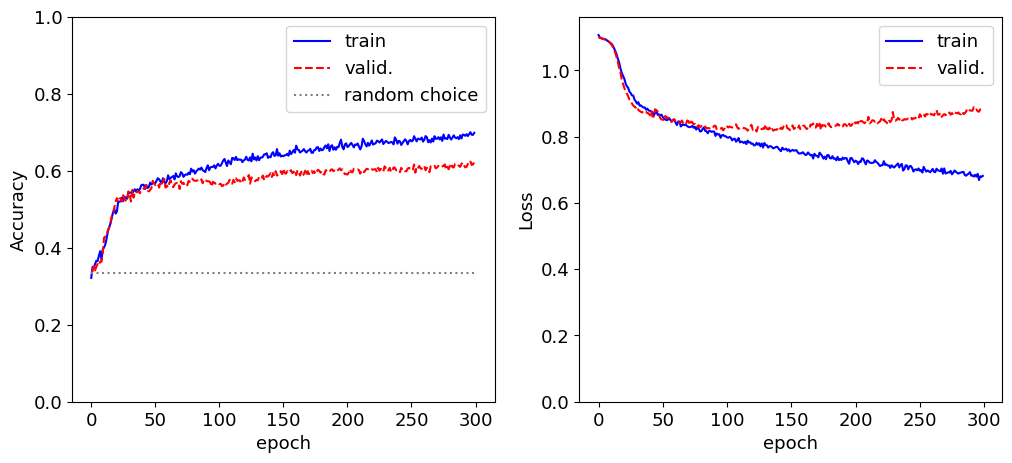

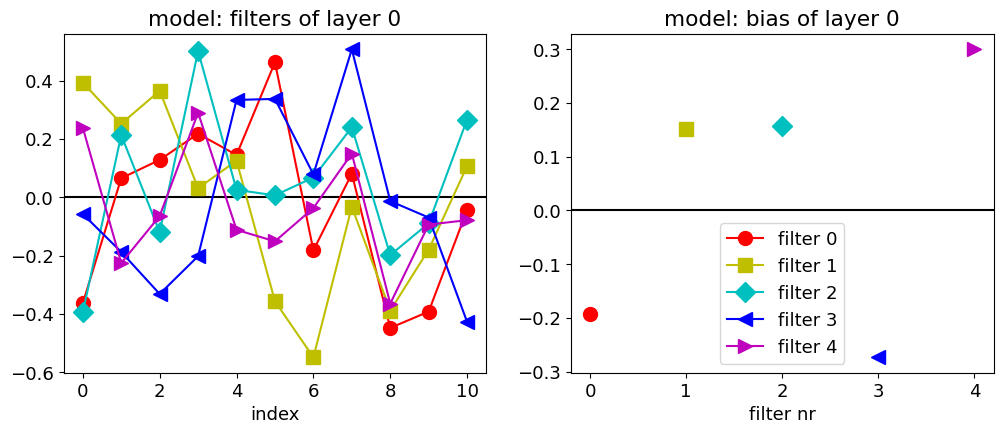

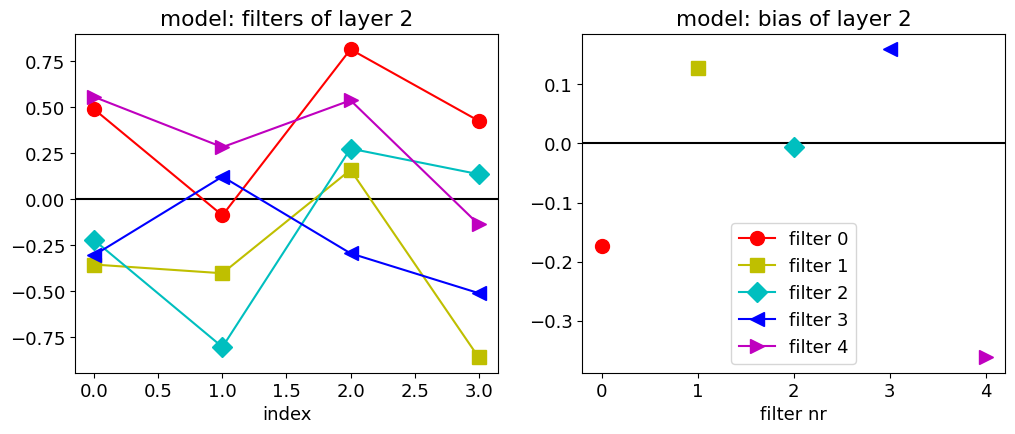

In [7]:
def Show_history(fit):
    fig,AX=plt.subplots(1,2,figsize=(12,5.))
    ax=AX[0]
    ax.plot(fit.history['accuracy'],"b",label="train")
    ax.plot(fit.history['val_accuracy'],"r--",label="valid.")
    ax.plot((0,EPOCHS),(1/3,1/3),":",c="gray",label="random choice")
    ax.set_xlabel('epoch')
    ax.set_ylabel("Accuracy")
    ax.set_ylim([0, 1])
    ax.legend()
    ax=AX[1]
    ax.plot(fit.history['loss'],"b",label="train")
    ax.plot(fit.history['val_loss'],"r--",label="valid.")
    ax.set_xlabel('epoch')
    ax.set_ylabel("Loss")
    ax.set_ylim([0, 1.05*np.max(fit.history['loss'])])
    ax.legend()
    plt.show()
Show_history(fit)
Show_weights(model,0)
Show_weights(model,2)

25/25 [==============================] - 0s 410us/step


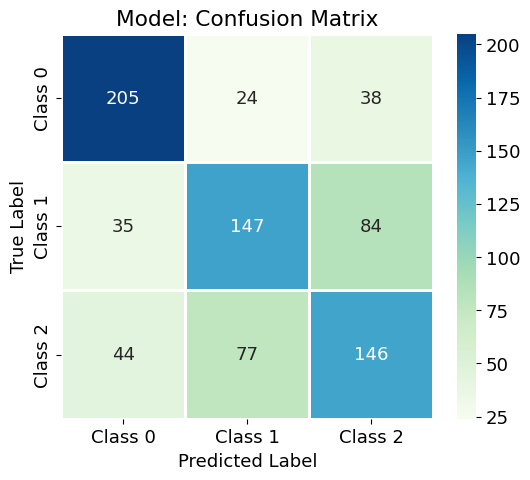

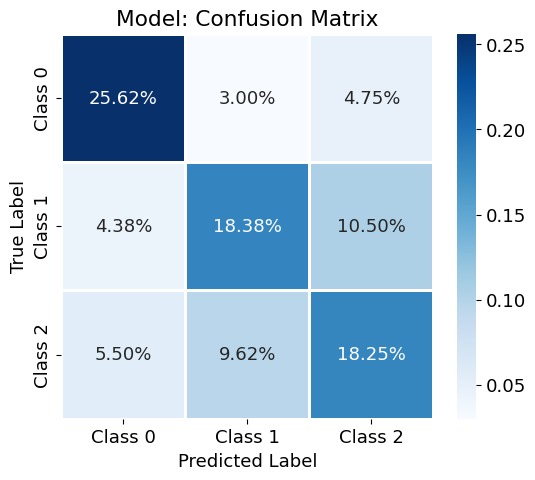

In [8]:
import pandas as pd
from scipy import stats

import seaborn 
from sklearn import metrics
from sklearn.metrics import classification_report
from sklearn import preprocessing

LABELS = ["Class 0","Class 1","Class 2"]

def show_confusion_matrix(validations, predictions, label="Model",perc=False):

    matrix = metrics.confusion_matrix(validations, predictions)
    plt.figure(figsize=(6, 5))
    M = matrix
    f = 'd'
    cmap="GnBu"
    if perc:
        M=M/np.sum(M)
        f='.2%'
        cmap='Blues'
    seaborn.heatmap(M,
                xticklabels=LABELS,
                yticklabels=LABELS,
                annot=True,
                fmt=f,
                linecolor='white',
                linewidths=1,
                cmap=cmap)
    plt.title(label+': Confusion Matrix')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

y_pred_val = np.array(model.predict(x_val))
# Take the class with the highest probability from the val predictions
max_y_pred_val = np.argmax(y_pred_val, axis=1)
max_y_val = np.argmax(y_val, axis=1)

show_confusion_matrix(max_y_val, max_y_pred_val)
show_confusion_matrix(max_y_val, max_y_pred_val,perc=True)

In [9]:
model2 = keras.models.clone_model(model)

reg2 = keras.regularizers.l2(0.5)
model2.layers[0].kernel_regularizer = reg2
model2.layers[1].kernel_regularizer = reg2
model2.layers[2].kernel_regularizer = reg2

opt = tf.keras.optimizers.legacy.Adam()
model2.compile(loss=keras.losses.categorical_crossentropy,optimizer=opt,metrics=['accuracy'])

BATCH_SIZE2 = 200
EPOCHS2 = 300

fit2 = model2.fit(x_train,y_train,batch_size=BATCH_SIZE2,epochs=EPOCHS2,
                validation_data=(x_val, y_val), verbose=2, shuffle=True) 

Epoch 1/300
16/16 - 0s - loss: 1.1321 - accuracy: 0.3406 - val_loss: 1.1062 - val_accuracy: 0.3162 - 232ms/epoch - 15ms/step
Epoch 2/300
16/16 - 0s - loss: 1.1068 - accuracy: 0.3359 - val_loss: 1.1007 - val_accuracy: 0.3413 - 36ms/epoch - 2ms/step
Epoch 3/300
16/16 - 0s - loss: 1.1026 - accuracy: 0.3403 - val_loss: 1.0981 - val_accuracy: 0.3512 - 38ms/epoch - 2ms/step
Epoch 4/300
16/16 - 0s - loss: 1.0986 - accuracy: 0.3472 - val_loss: 1.0964 - val_accuracy: 0.3537 - 41ms/epoch - 3ms/step
Epoch 5/300
16/16 - 0s - loss: 1.0957 - accuracy: 0.3553 - val_loss: 1.0953 - val_accuracy: 0.3575 - 38ms/epoch - 2ms/step
Epoch 6/300
16/16 - 0s - loss: 1.0934 - accuracy: 0.3653 - val_loss: 1.0932 - val_accuracy: 0.3663 - 37ms/epoch - 2ms/step
Epoch 7/300
16/16 - 0s - loss: 1.0901 - accuracy: 0.3681 - val_loss: 1.0909 - val_accuracy: 0.3675 - 39ms/epoch - 2ms/step
Epoch 8/300
16/16 - 0s - loss: 1.0867 - accuracy: 0.3884 - val_loss: 1.0884 - val_accuracy: 0.3738 - 42ms/epoch - 3ms/step
Epoch 9/300
16

Epoch 68/300
16/16 - 0s - loss: 0.8201 - accuracy: 0.6178 - val_loss: 0.8419 - val_accuracy: 0.5813 - 42ms/epoch - 3ms/step
Epoch 69/300
16/16 - 0s - loss: 0.8125 - accuracy: 0.6219 - val_loss: 0.8398 - val_accuracy: 0.5863 - 41ms/epoch - 3ms/step
Epoch 70/300
16/16 - 0s - loss: 0.8133 - accuracy: 0.6187 - val_loss: 0.8428 - val_accuracy: 0.5875 - 41ms/epoch - 3ms/step
Epoch 71/300
16/16 - 0s - loss: 0.8162 - accuracy: 0.6084 - val_loss: 0.8420 - val_accuracy: 0.5863 - 39ms/epoch - 2ms/step
Epoch 72/300
16/16 - 0s - loss: 0.8097 - accuracy: 0.6175 - val_loss: 0.8388 - val_accuracy: 0.5925 - 38ms/epoch - 2ms/step
Epoch 73/300
16/16 - 0s - loss: 0.8123 - accuracy: 0.6181 - val_loss: 0.8432 - val_accuracy: 0.5825 - 38ms/epoch - 2ms/step
Epoch 74/300
16/16 - 0s - loss: 0.8176 - accuracy: 0.6128 - val_loss: 0.8399 - val_accuracy: 0.5888 - 38ms/epoch - 2ms/step
Epoch 75/300
16/16 - 0s - loss: 0.8051 - accuracy: 0.6256 - val_loss: 0.8423 - val_accuracy: 0.5850 - 38ms/epoch - 2ms/step
Epoch 76

Epoch 134/300
16/16 - 0s - loss: 0.7350 - accuracy: 0.6784 - val_loss: 0.8199 - val_accuracy: 0.6112 - 39ms/epoch - 2ms/step
Epoch 135/300
16/16 - 0s - loss: 0.7361 - accuracy: 0.6772 - val_loss: 0.8205 - val_accuracy: 0.6150 - 38ms/epoch - 2ms/step
Epoch 136/300
16/16 - 0s - loss: 0.7404 - accuracy: 0.6737 - val_loss: 0.8192 - val_accuracy: 0.6200 - 38ms/epoch - 2ms/step
Epoch 137/300
16/16 - 0s - loss: 0.7405 - accuracy: 0.6706 - val_loss: 0.8269 - val_accuracy: 0.6087 - 38ms/epoch - 2ms/step
Epoch 138/300
16/16 - 0s - loss: 0.7351 - accuracy: 0.6687 - val_loss: 0.8235 - val_accuracy: 0.6150 - 39ms/epoch - 2ms/step
Epoch 139/300
16/16 - 0s - loss: 0.7388 - accuracy: 0.6687 - val_loss: 0.8191 - val_accuracy: 0.6137 - 38ms/epoch - 2ms/step
Epoch 140/300
16/16 - 0s - loss: 0.7292 - accuracy: 0.6781 - val_loss: 0.8198 - val_accuracy: 0.6150 - 38ms/epoch - 2ms/step
Epoch 141/300
16/16 - 0s - loss: 0.7329 - accuracy: 0.6812 - val_loss: 0.8216 - val_accuracy: 0.6125 - 38ms/epoch - 2ms/step


Epoch 200/300
16/16 - 0s - loss: 0.6919 - accuracy: 0.6981 - val_loss: 0.8305 - val_accuracy: 0.6062 - 48ms/epoch - 3ms/step
Epoch 201/300
16/16 - 0s - loss: 0.6913 - accuracy: 0.7003 - val_loss: 0.8213 - val_accuracy: 0.6250 - 42ms/epoch - 3ms/step
Epoch 202/300
16/16 - 0s - loss: 0.6893 - accuracy: 0.7050 - val_loss: 0.8234 - val_accuracy: 0.6288 - 43ms/epoch - 3ms/step
Epoch 203/300
16/16 - 0s - loss: 0.6876 - accuracy: 0.7006 - val_loss: 0.8194 - val_accuracy: 0.6313 - 44ms/epoch - 3ms/step
Epoch 204/300
16/16 - 0s - loss: 0.6836 - accuracy: 0.7091 - val_loss: 0.8274 - val_accuracy: 0.6200 - 42ms/epoch - 3ms/step
Epoch 205/300
16/16 - 0s - loss: 0.6880 - accuracy: 0.7066 - val_loss: 0.8264 - val_accuracy: 0.6250 - 41ms/epoch - 3ms/step
Epoch 206/300
16/16 - 0s - loss: 0.6925 - accuracy: 0.7031 - val_loss: 0.8237 - val_accuracy: 0.6225 - 43ms/epoch - 3ms/step
Epoch 207/300
16/16 - 0s - loss: 0.6866 - accuracy: 0.7088 - val_loss: 0.8278 - val_accuracy: 0.6200 - 39ms/epoch - 2ms/step


Epoch 266/300
16/16 - 0s - loss: 0.6605 - accuracy: 0.7119 - val_loss: 0.8327 - val_accuracy: 0.6275 - 46ms/epoch - 3ms/step
Epoch 267/300
16/16 - 0s - loss: 0.6603 - accuracy: 0.7128 - val_loss: 0.8335 - val_accuracy: 0.6250 - 45ms/epoch - 3ms/step
Epoch 268/300
16/16 - 0s - loss: 0.6525 - accuracy: 0.7219 - val_loss: 0.8343 - val_accuracy: 0.6313 - 44ms/epoch - 3ms/step
Epoch 269/300
16/16 - 0s - loss: 0.6536 - accuracy: 0.7184 - val_loss: 0.8325 - val_accuracy: 0.6263 - 44ms/epoch - 3ms/step
Epoch 270/300
16/16 - 0s - loss: 0.6488 - accuracy: 0.7203 - val_loss: 0.8432 - val_accuracy: 0.6175 - 43ms/epoch - 3ms/step
Epoch 271/300
16/16 - 0s - loss: 0.6547 - accuracy: 0.7147 - val_loss: 0.8382 - val_accuracy: 0.6313 - 43ms/epoch - 3ms/step
Epoch 272/300
16/16 - 0s - loss: 0.6619 - accuracy: 0.7134 - val_loss: 0.8312 - val_accuracy: 0.6325 - 41ms/epoch - 3ms/step
Epoch 273/300
16/16 - 0s - loss: 0.6541 - accuracy: 0.7125 - val_loss: 0.8405 - val_accuracy: 0.6275 - 41ms/epoch - 3ms/step


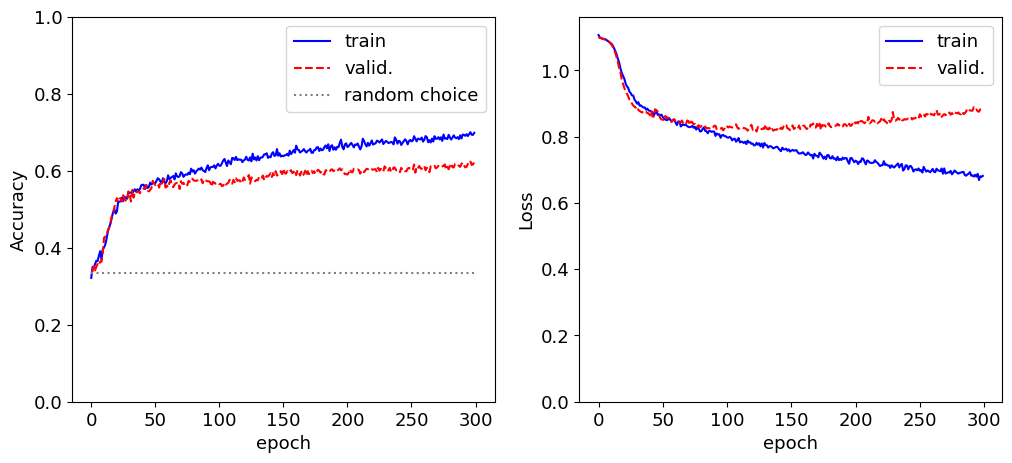

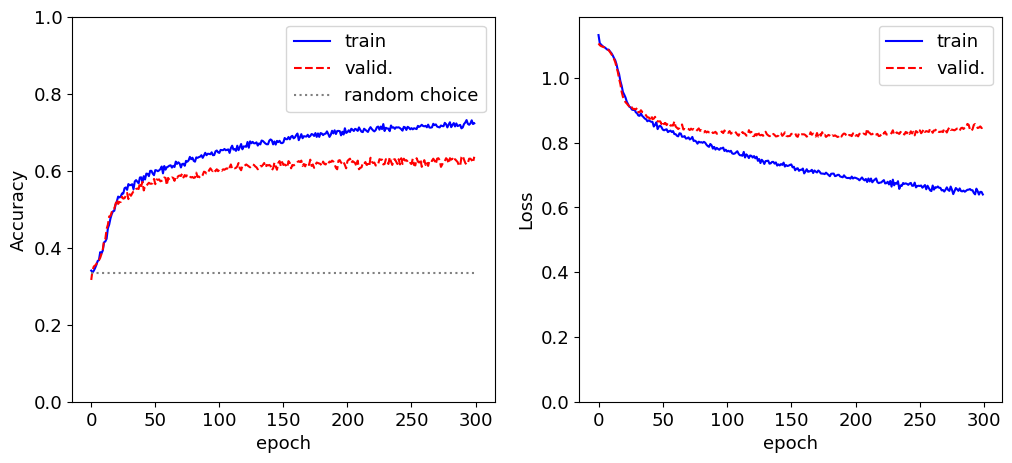

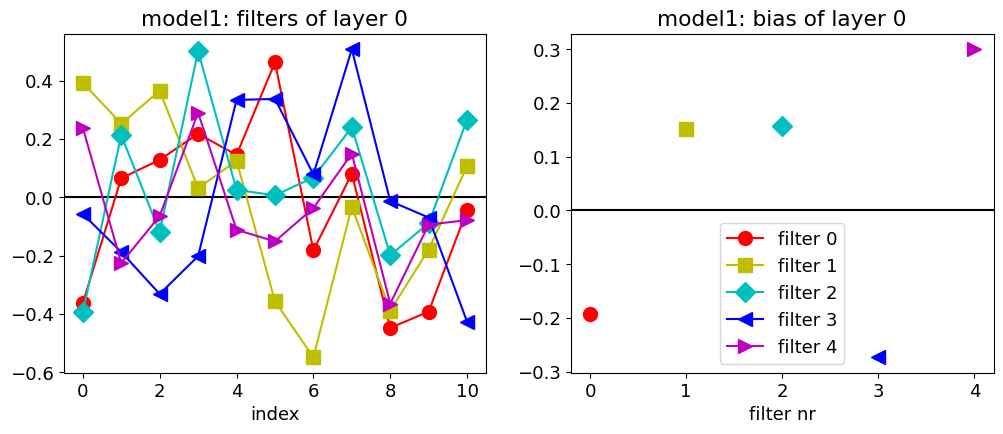

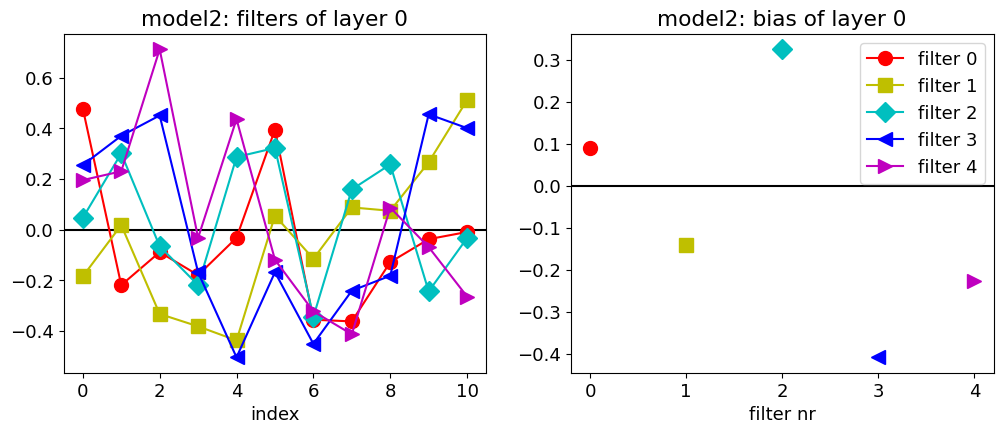

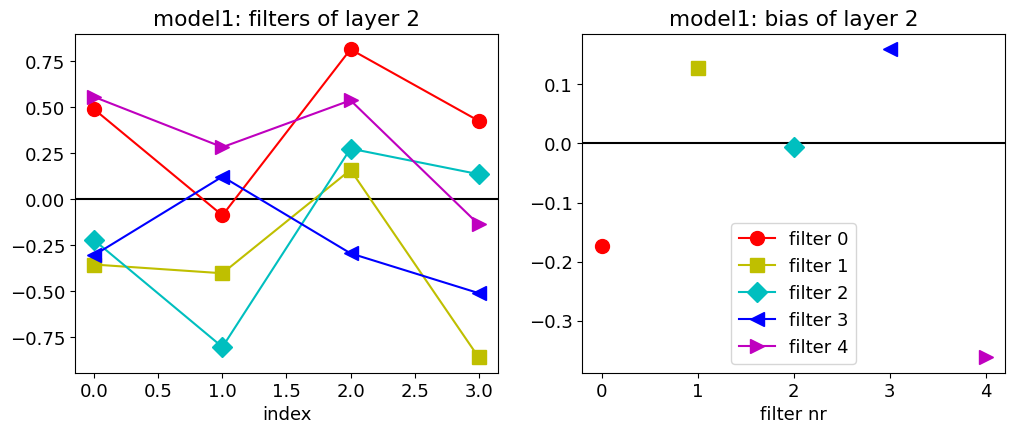

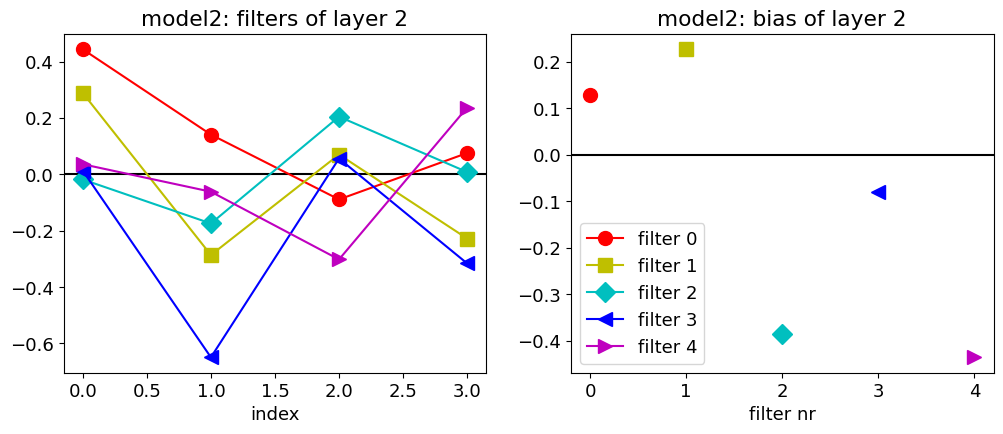

25/25 [==============================] - 0s 395us/step


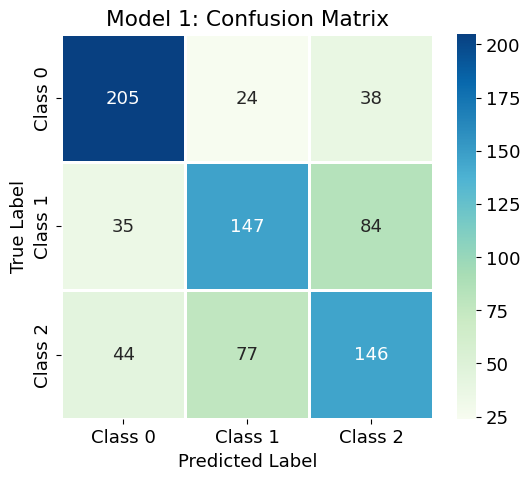

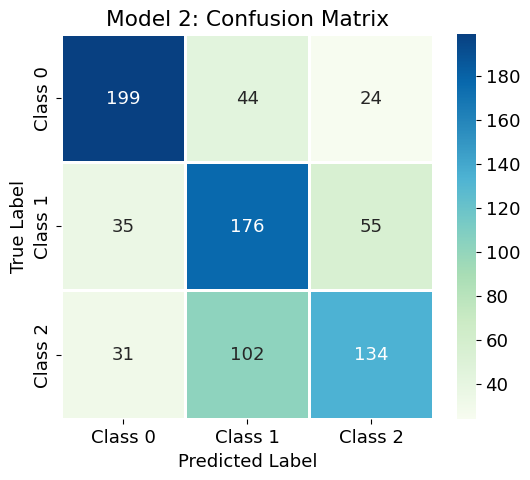

In [10]:

Show_history(fit)
Show_history(fit2)

Show_weights(model,0,label="model1")
Show_weights(model2,0,label="model2")
Show_weights(model,2,label="model1")
Show_weights(model2,2,label="model2")


y_pred_val2 = model2.predict(x_val)
# Take the class with the highest probability from the val predictions
max_y_pred_val2 = np.argmax(y_pred_val2, axis=1)

show_confusion_matrix(max_y_val, max_y_pred_val, label="Model 1")
show_confusion_matrix(max_y_val, max_y_pred_val2, label="Model 2")